<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/Practical2_MV_CM23004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib numpy --quiet

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()

Saving mobile.jpg to mobile.jpg


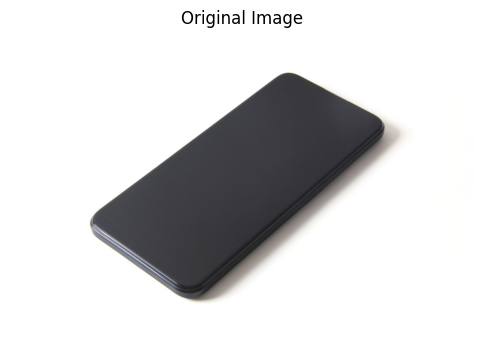

In [4]:
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

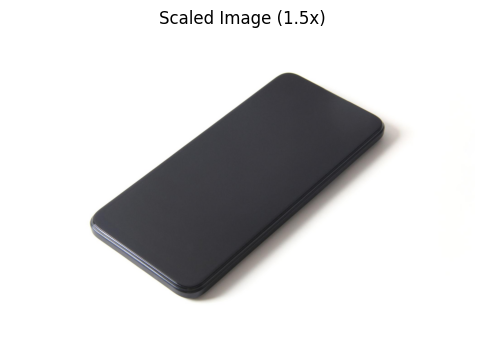

In [5]:
scaled = cv2.resize(img, None, fx=1.5, fy=1.5)

plt.figure(figsize=(6,6))
plt.imshow(scaled)
plt.title("Scaled Image (1.5x)")
plt.axis("off")
plt.show()

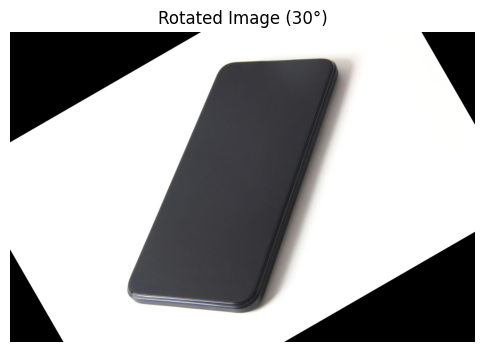

In [6]:
h, w = img.shape[:2]

center = (w//2, h//2)

rotation_matrix = cv2.getRotationMatrix2D(center, 30, 1)

rotated = cv2.warpAffine(img, rotation_matrix, (w, h))

plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.title("Rotated Image (30°)")
plt.axis("off")
plt.show()

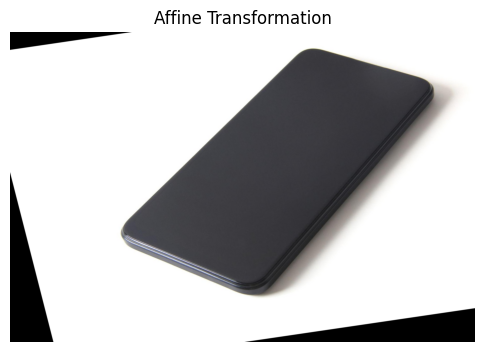

In [7]:
rows, cols = img.shape[:2]

pts1 = np.float32([[300,150],
                   [900,200],
                   [350,700]])

pts2 = np.float32([[250,200],
                   [950,150],
                   [450,750]])

matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(img, matrix, (cols, rows))

plt.figure(figsize=(6,6))
plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

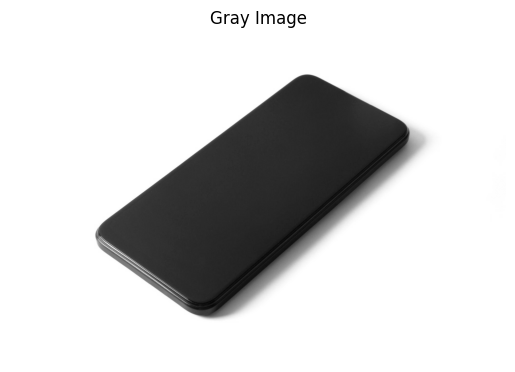

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Gray Image")
plt.axis("off")
plt.show()

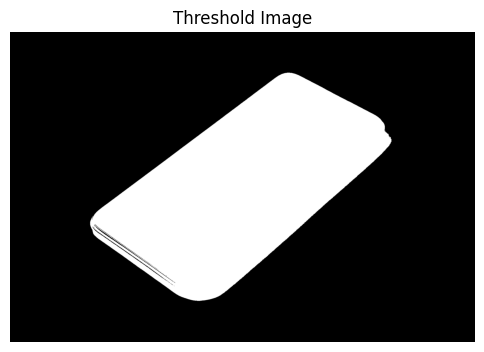

In [9]:
_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

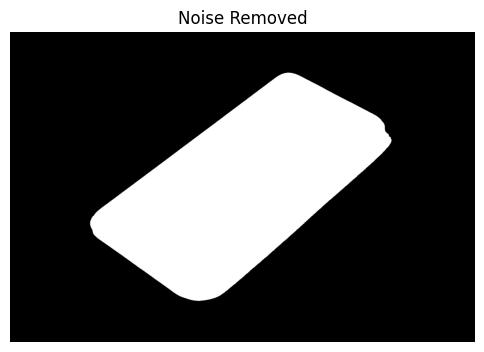

In [10]:
kernel = np.ones((5,5), np.uint8)

thresh = cv2.morphologyEx(thresh,
                          cv2.MORPH_CLOSE,
                          kernel)

plt.figure(figsize=(6,6))
plt.imshow(thresh,cmap='gray')
plt.title("Noise Removed")
plt.axis("off")
plt.show()

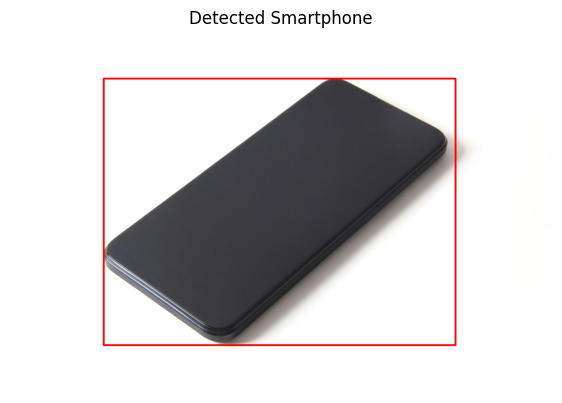

In [11]:
contours, _ = cv2.findContours(thresh,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

largest = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest)

output = img.copy()

cv2.rectangle(output,
              (x,y),
              (x+w,y+h),
              (255,0,0),
              5)

plt.figure(figsize=(7,7))
plt.imshow(output)
plt.title("Detected Smartphone")
plt.axis("off")
plt.show()

In [12]:
print("Width in Pixels :", w)
print("Height in Pixels:", h)

area = w*h

print("Bounding Box Area:", area, "pixels")

Width in Pixels : 1327
Height in Pixels: 1005
Bounding Box Area: 1333635 pixels


In [13]:
pixel_to_mm = 0.10

width_mm = w * pixel_to_mm
height_mm = h * pixel_to_mm

print("Estimated Width :", round(width_mm,2),"mm")
print("Estimated Height:", round(height_mm,2),"mm")

Estimated Width : 132.7 mm
Estimated Height: 100.5 mm


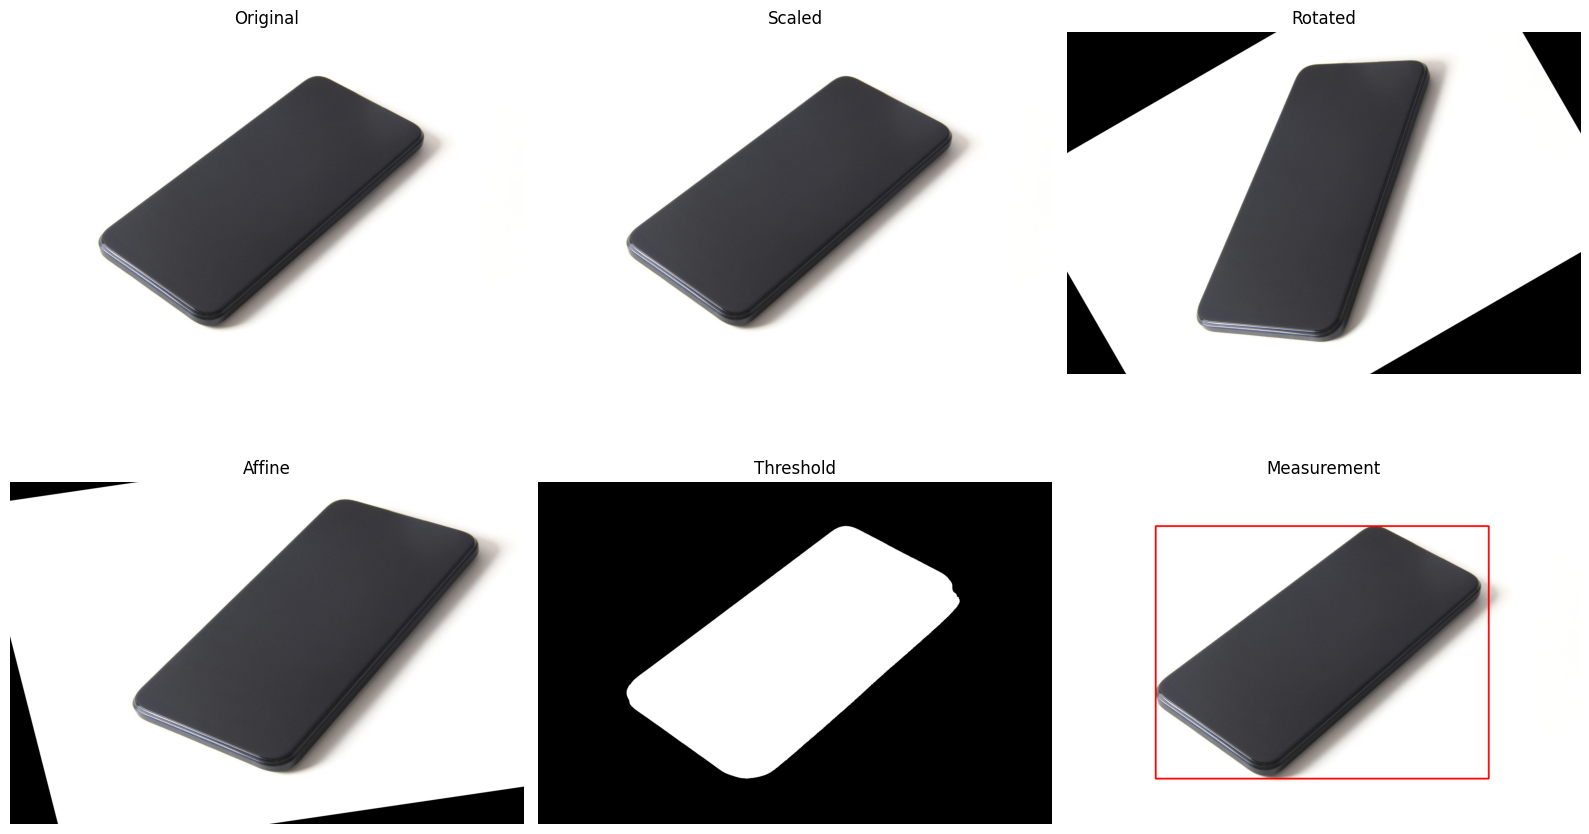

In [14]:
fig, ax = plt.subplots(2,3, figsize=(16,10))

ax[0,0].imshow(img)
ax[0,0].set_title("Original")

ax[0,1].imshow(scaled)
ax[0,1].set_title("Scaled")

ax[0,2].imshow(rotated)
ax[0,2].set_title("Rotated")

ax[1,0].imshow(affine)
ax[1,0].set_title("Affine")

ax[1,1].imshow(thresh,cmap='gray')
ax[1,1].set_title("Threshold")

ax[1,2].imshow(output)
ax[1,2].set_title("Measurement")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()